# TFIM Toy Example: from Raw Snapshots to a Learned Distance Matrix

In this tutorial, you can assume TFIM physics and general Python background. You do not need
prior knowledge of this codebase. As we run the workflow together, we explain each object at
first use.

By the end, we will have:
- converted flat raw `.npy` files into the folder layout expected by the package,
- trained `DistanceLearningPipeline` for `L = 64, 128, 256`,
- produced and plotted one Hellinger distance matrix per system size.


## What `born2disc` is (in plain language)

`born2disc` is the package in this repository that takes measurement snapshots from many
phase-diagram points and trains a classifier to distinguish those points. It then converts
classifier outputs into a matrix of pairwise distances between points.

In this notebook, you will use it as a tool: we prepare data, run the pipeline, and read the
resulting distance matrices. We assume the detailed theory is in the paper.


## Before we run

If you followed the installation and data-download instructions in `README.md`, your data and
environment should already be in place.

Practical notes:
- this notebook uses only the x-basis toy data,
- training is CPU-friendly but can still take time,
- we set `num_workers = 0` in notebook training to avoid multiprocessing pickle issues.


In [1]:
import os
import re
import sys
import pickle
from pathlib import Path

import numpy as np
import torch as pt
from matplotlib import pyplot as plt

from born2disc.classification_backbones.feedforward import FeedforwardClassificationBackboneConfig
from born2disc.pipelines.distance_learning_pipeline import DistanceLearningPipeline


## 1) Set up folder variables

First, we define variables for where your raw data is and where we can store optional outputs.
If you followed the `README.md` setup, these paths should work without changes.


In [2]:
if Path.cwd().name == "toy_examples":
    NOTEBOOK_DIR = Path.cwd().resolve()
else:
    NOTEBOOK_DIR = (Path.cwd().resolve() / "toy_examples").resolve()

if not NOTEBOOK_DIR.exists():
    raise FileNotFoundError(
        f"Could not find toy_examples directory at {NOTEBOOK_DIR}. Run from repo root or toy_examples/."
    )

REPO_ROOT = NOTEBOOK_DIR.parent
RAW_DIR = REPO_ROOT / "data" / "tfim" / "raw_snapshots"
PREPARED_DIR = NOTEBOOK_DIR / "data" / "tfim_prepared"
SAVE_ROOT_DIR = NOTEBOOK_DIR / "outputs" / "save_root"
FIGURE_DIR = NOTEBOOK_DIR / "outputs" / "figures"

for output_path in (PREPARED_DIR, SAVE_ROOT_DIR, FIGURE_DIR):
    output_path.mkdir(parents=True, exist_ok=True)

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"NOTEBOOK_DIR: {NOTEBOOK_DIR}")
print(f"RAW_DIR: {RAW_DIR} (exists={RAW_DIR.exists()})")
print(f"PREPARED_DIR: {PREPARED_DIR}")
print(f"SAVE_ROOT_DIR: {SAVE_ROOT_DIR}")
print(f"FIGURE_DIR: {FIGURE_DIR}")


NOTEBOOK_DIR: /scratch/malyshev/Research/quantum_many_body_distance_learning/toy_examples
RAW_DIR: /scratch/malyshev/Research/quantum_many_body_distance_learning/data/tfim/raw_snapshots (exists=True)
PREPARED_DIR: /scratch/malyshev/Research/quantum_many_body_distance_learning/toy_examples/data/tfim_prepared
SAVE_ROOT_DIR: /scratch/malyshev/Research/quantum_many_body_distance_learning/toy_examples/outputs/save_root
FIGURE_DIR: /scratch/malyshev/Research/quantum_many_body_distance_learning/toy_examples/outputs/figures


## 2) Import `PhaseDiagramPointConfig` from a module

`data_descr.pickle` stores point-config objects. We import the class from a normal `.py`
module (instead of defining it inside the notebook) so worker processes can deserialize it
without errors.


In [3]:
from tfim_point_config import PhaseDiagramPointConfig

BASIS_PREFIX_DICT = {"x": "x_"}
BASIS_LABEL_DICT = {"x": -0.5}

RAW_FILENAME_PATTERN = re.compile(
    r"^system_size_(?P<system_size>\d+)_transverse_field_(?P<transverse_field>[0-9eE+\-.]+)\.npy$"
)


## 3) Convert raw files into the structured dataset format

Your raw files are flat. Each filename encodes one phase-diagram point:
- `system_size_X` gives lattice size `L`,
- `transverse_field_Y` gives control parameter `h`.

We convert these into nested folders using `point_config.to_path_suffix()`, save
`x_snapshots.npy` inside each point folder, and create `data_descr.pickle`.

`data_descr.pickle` is the index file that tells the pipeline which points exist.

Important: we do **not** save `x_basis_labelled_snapshots.npy`; the pipeline appends basis
labels internally when it loads snapshots.


In [4]:
def parse_raw_filename(*, raw_path: Path) -> tuple[int, float]:
    match = RAW_FILENAME_PATTERN.match(raw_path.name)
    if match is None:
        raise ValueError(f"Unexpected raw filename format: {raw_path.name}")

    system_size = int(match.group("system_size"))
    transverse_field = float(match.group("transverse_field"))
    return system_size, transverse_field


def prepare_tfim_dataset_from_raw(*, raw_dir: Path, prepared_dir: Path) -> set:
    """Convert flat raw files into the nested folder format expected by DistanceLearningPipeline."""
    if not raw_dir.exists():
        raise FileNotFoundError(f"Raw directory not found: {raw_dir}")

    raw_file_paths = sorted(raw_dir.glob("system_size_*_transverse_field_*.npy"))
    if len(raw_file_paths) == 0:
        raise RuntimeError(f"No raw snapshot files found in: {raw_dir}")

    data_descr = set()

    for raw_path in raw_file_paths:
        system_size, transverse_field = parse_raw_filename(raw_path=raw_path)

        x_snapshots = np.load(file=raw_path)
        if x_snapshots.ndim != 2:
            raise ValueError(
                f"Expected rank-2 snapshots in {raw_path}, got shape={x_snapshots.shape}"
            )
        if x_snapshots.shape[1] != system_size:
            raise ValueError(
                f"Feature mismatch in {raw_path}: expected {system_size}, got {x_snapshots.shape[1]}"
            )

        point_config = PhaseDiagramPointConfig(
            system_size=system_size,
            transverse_field=transverse_field,
        )

        point_directory = prepared_dir / point_config.to_path_suffix()
        point_directory.mkdir(parents=True, exist_ok=True)
        np.save(file=point_directory / "x_snapshots.npy", arr=x_snapshots)

        data_descr.add(point_config)

    with open(prepared_dir / "data_descr.pickle", "wb") as handle:
        pickle.dump(data_descr, handle, protocol=pickle.HIGHEST_PROTOCOL)

    return data_descr


In [5]:
data_descr = prepare_tfim_dataset_from_raw(raw_dir=RAW_DIR, prepared_dir=PREPARED_DIR)
print(f"Prepared points: {len(data_descr)}")

system_sizes_found = sorted({point.system_size for point in data_descr})
print(f"System sizes found: {system_sizes_found}")

for system_size in system_sizes_found:
    num_points = sum(1 for point in data_descr if point.system_size == system_size)
    print(f"L={system_size}: {num_points} transverse-field points")


Prepared points: 1005
System sizes found: [16, 32, 64, 128, 256]
L=16: 201 transverse-field points
L=32: 201 transverse-field points
L=64: 201 transverse-field points
L=128: 201 transverse-field points
L=256: 201 transverse-field points


## 4) Define the callback functions for `DistanceLearningPipeline`

The pipeline is generic, so we provide small functions (callbacks) that answer TFIM-specific
questions during loading and validation:
- which points to keep (`filter`),
- how many features each snapshot should have (`input_size`),
- whether loaded data is valid (`sanity_check`),
- how to order points along the control parameter (`sorting`).

If callbacks are new to you, think of them as small helper rules that the pipeline calls when
it needs a TFIM-specific decision.


In [6]:
def generate_filter_lambda(system_size: int):
    """Return a callback that keeps only one fixed system size."""

    def filter_lambda(point_config):
        return point_config.system_size == system_size

    return filter_lambda


def input_size_lambda(point_config):
    """Return physical snapshot width (without basis label)."""
    return point_config.system_size


def sanity_check_lambda(point_config, snapshots: pt.Tensor):
    """Validate snapshot feature count against system size."""
    if snapshots.shape[1] != point_config.system_size:
        return False, (
            f"Snapshots have {snapshots.shape[1]} features, expected {point_config.system_size}."
        )
    return True, ""


def sorting_lambda(single_point_datasets):
    """Sort datasets by transverse field so matrix axes follow physical order."""
    return sorted(
        single_point_datasets,
        key=lambda single_point_dataset: single_point_dataset.config.transverse_field,
    )


## 5) Choose a simple single-run training setup

To keep this tutorial focused, we use:
- one run per system size (`L = 64, 128, 256`),
- no seed averaging in this notebook,
- one divergence for plotting (`hellinger`).


In [7]:
SYSTEM_SIZES = (64, 128, 256)
SAMPLES_PER_POINT = 5000
HIDDEN_SIZE = 256
MAX_EPOCHS = 100
DIVERGENCE_NAME = "hellinger"


## 6) Train and extract one distance matrix per system size

For each `L`, we initialize a fresh pipeline, train once, compute the Hellinger matrix, and
store both the matrix and the ordered transverse-field coordinates (should take roughly 10 minutes).


In [ ]:
pipelines = {}
f_matrices = {}
f_matrices_std = {}
coords_dict = {}

for system_size in SYSTEM_SIZES:
    print(f"\nRunning DistanceLearningPipeline for L={system_size}")

    classification_backbone_config = FeedforwardClassificationBackboneConfig(
        num_hidden_layers=5,
        hidden_size=HIDDEN_SIZE,
    )

    pipeline = DistanceLearningPipeline(
        snapshots_root_dir=str(PREPARED_DIR),
        save_root_dir=str(SAVE_ROOT_DIR),
        phase_diagram_config=None,
        embedding_size=HIDDEN_SIZE,
        filter_lambda=generate_filter_lambda(system_size=system_size),
        input_size_lambda=input_size_lambda,
        train_and_test_ratio=0.75,
        train4train_ratio=0.75,
        train4calibration_ratio=0.75,
        bases_to_include=("x",),
        basis_prefix_dict=BASIS_PREFIX_DICT,
        basis_label_dict=BASIS_LABEL_DICT,
        sanity_check_lambda=sanity_check_lambda,
        sorting_lambda=sorting_lambda,
        snapshots_per_point=SAMPLES_PER_POINT,
        classification_backbone_config=classification_backbone_config,
        max_epochs=MAX_EPOCHS,
        learning_rate=1e-4,
        rng_seed=0,
    )

    pipeline.early_stopping_config.patience = 5
    pipeline.early_stopping_config.min_delta = 1e-3

    # Notebook-safe multiprocessing setting.
    pipeline.data_module.num_workers = 0

    pipeline.run_training()

    f_matrix, f_matrix_std = pipeline.calculate_f_divergences_matrix(
        divergence=DIVERGENCE_NAME,
        selector="test",
    )

    transverse_fields = np.asarray(
        [dataset.config.transverse_field for dataset in pipeline.single_point_datasets],
        dtype=float,
    )

    pipelines[system_size] = pipeline
    f_matrices[system_size] = f_matrix
    f_matrices_std[system_size] = f_matrix_std
    coords_dict[system_size] = transverse_fields

with open(FIGURE_DIR / "tfim_toy_single_run_results.pickle", "wb") as handle:
    pickle.dump(
        {
            "coords_dict": coords_dict,
            "f_matrices": f_matrices,
            "f_matrices_std": f_matrices_std,
        },
        handle,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

print("Saved: tfim_toy_single_run_results.pickle")



Running DistanceLearningPipeline for L=64
201 single point datasets created


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/scratch/malyshev/Research/quantum_many_body_distance_learning/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/scratch/malyshev/Research/quantum_many_body_distance_learning/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlog

We use symmetry pooling: False


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/scratch/malyshev/Research/quantum_many_body_distance_learning/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/scratch/malyshev/Research/quantum_many_body_distance_learning/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/scratch/malyshev/Research/quantum_many_body_distance_learning/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## 7) Plot matrices with physical axes (`h`, not point index)

Each panel shows the pairwise learned distance between phase-diagram points at fixed `L`.
In this step, we place the true transverse-field values on both axes, so you can read each
matrix element directly as distance between `(h_i, h_j)`.


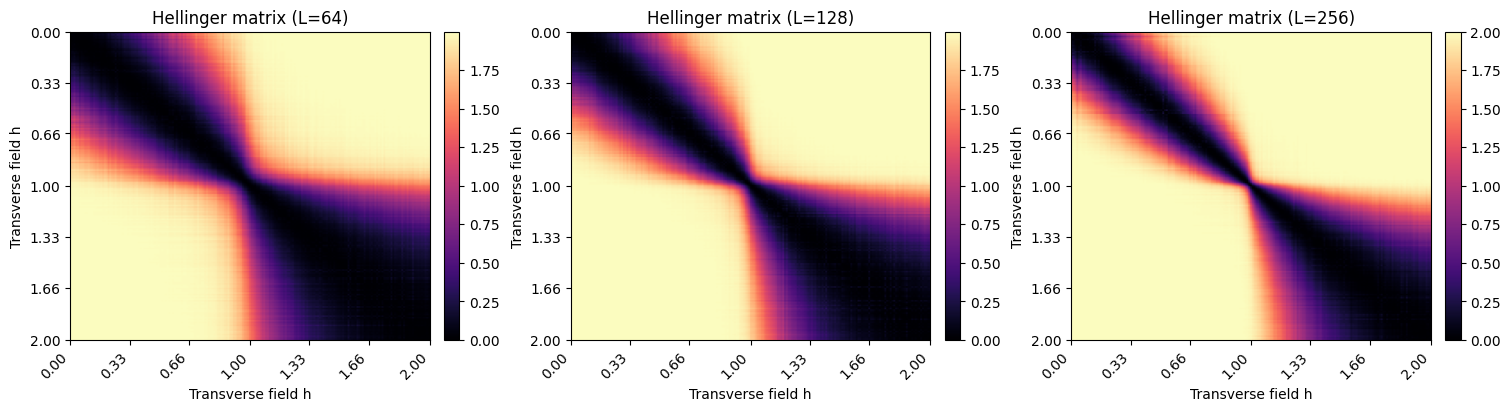

Saved figure: tfim_toy_hellinger_matrices_vs_h.png


In [12]:
def select_tick_values(*, fields: np.ndarray, target_num_ticks: int = 7) -> np.ndarray:
    if len(fields) <= target_num_ticks:
        return fields

    tick_indices = np.linspace(0, len(fields) - 1, num=target_num_ticks, dtype=int)
    tick_indices = np.unique(tick_indices)
    return fields[tick_indices]


figure, axes = plt.subplots(
    nrows=1,
    ncols=len(SYSTEM_SIZES),
    figsize=(5 * len(SYSTEM_SIZES), 4),
    constrained_layout=True,
)
if len(SYSTEM_SIZES) == 1:
    axes = [axes]

for axis, system_size in zip(axes, SYSTEM_SIZES):
    fields = coords_dict[system_size]
    symmetric_f_matrix = 0.5 * (f_matrices[system_size] + f_matrices[system_size].T)
    matrix_numpy = symmetric_f_matrix.detach().cpu().numpy()

    matrix_image = axis.imshow(
        matrix_numpy,
        cmap="magma",
        extent=[fields.min(), fields.max(), fields.max(), fields.min()],
        origin="upper",
        aspect="auto",
    )

    tick_values = select_tick_values(fields=fields, target_num_ticks=7)
    axis.set_xticks(tick_values)
    axis.set_yticks(tick_values)
    axis.set_xticklabels([f"{value:.2f}" for value in tick_values], rotation=45, ha="right")
    axis.set_yticklabels([f"{value:.2f}" for value in tick_values])

    axis.set_xlabel("Transverse field h")
    axis.set_ylabel("Transverse field h")
    axis.set_title(f"{DIVERGENCE_NAME.title()} matrix (L={system_size})")
    figure.colorbar(matrix_image, ax=axis, fraction=0.046, pad=0.04)

figure.savefig(FIGURE_DIR / "tfim_toy_hellinger_matrices_vs_h.png", dpi=200)
plt.show()

print("Saved figure: tfim_toy_hellinger_matrices_vs_h.png")


## Troubleshooting

- **No raw files found**: check that `tfim/raw_snapshots/` exists and contains files named
  `system_size_X_transverse_field_Y.npy`.
- **Shape mismatch error**: each array must have shape `(num_snapshots, system_size)`.
- **Training is slow**: reduce `SAMPLES_PER_POINT` and/or `MAX_EPOCHS` for a quick test run.
- **Multiprocessing/pickle errors**: keep `pipeline.data_module.num_workers = 0` in notebooks.


## Next steps (outside this tutorial)

This notebook is single-run by design. If you want to extend it, we can add:
- seed averaging with uncertainty estimates,
- additional divergences (`triangular`, `jensen_shannon`),
- x+z basis runs when z-basis raw snapshots are available.
